# Time evolution of $\mathrm{Yb}$ spin-orbit coupled system with 2-body loss

- Units
    - $\hbar=1.0545\times 10^{-34} \,\mathrm{J}\cdot\mathrm{s}$
    - $E_r/\hbar = 8.8593 \,\mathrm{kHz}$
    - $k_r = \sin\left(\frac{\theta}{2}\right)\frac{2\pi}{556 \,\mathrm{nm}} = 6.9462\times10^6 \, \mathrm{m}^{-1}$

Where $\theta=75.854^\circ$
  
- Derived Units
    - $t_r = \hbar/E_r = 0.1129 \,\mathrm{ms}$
    - $m_r = \hbar^2 k_r^2 / 2 E_r = m_{\mathrm{Yb}} = 2.872×10^{-25} \, \mathrm{kg}$

- Hamiltonian
  
$$
\begin{equation}
    H=\sum_{\mathbf{k}}
    \begin{pmatrix}
        c_{\uparrow}^\dagger(\mathbf{k}) & c_{\downarrow}^\dagger(\mathbf{k})
    \end{pmatrix}
    \begin{pmatrix}
        \frac{\hbar^2(q_x-k_r)^2}{2m_{\mathrm{Yb}}} + \frac{\delta}{2} & \frac{\Omega_R}{2} \\
        \frac{\Omega_R}{2} & \frac{\hbar^2(q_x+k_r)^2}{2m_{\mathrm{Yb}}}-\frac{\delta}{2}
    \end{pmatrix}
    \begin{pmatrix}
        c_{\uparrow}(\mathbf{k}) \\
        c_{\downarrow}(\mathbf{k})
    \end{pmatrix}
    -\frac{1}{N}\frac{i}{2}\gamma\sum_{\mathbf{k}, \mathbf{k}', \mathbf{q}}c_\downarrow^\dagger(\mathbf{k}'+\mathbf{q})c_\uparrow^\dagger(\mathbf{k}-\mathbf{q})c_\uparrow(\mathbf{k})c_\downarrow(\mathbf{k}')
\end{equation}
$$

$q_x=[-2.5 k_r, ..., -0.5 k_r, 0, 0.5 k_r, k_r, ..., 3 k_r]$ for $L=12$

- parameters
  - $\hbar/\hbar = 1$
  - $k_r/k_r = 1$
  - $m_{\mathrm{Yb}}/m_r = 1$
  - $\delta/E_r = 4$
  - $\Omega_R/E_r = 3.5$
  - $\gamma/E_r = 0.25$


- basis
  
$$\mathcal{B}= \{c_{\sigma_1}^\dagger(\mathbf{k}_1)c_{\sigma_2}^\dagger(\mathbf{k}_2)\cdots c_{\sigma_n}^\dagger(\mathbf{k}_n)\ket{0}:\sigma_j=\uparrow,\downarrow, i_{\mathbf{k}_1}<i_{\mathbf{k}_2}<\cdots<i_{\mathbf{k}_n}\}$$
$$[H]_{\mathcal{B}}$$

In [1]:
!unzip opalg

'unzip'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


imports

In [29]:
import json
import os
import itertools

# import jax
# jax.config.update("jax_enable_x64", True)
# jax.config.update('jax_platform_name', 'cpu')
# import jax.numpy as jnp

import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

from einops import rearrange

from quant_mech import hilbert, ybsoc

drive mount & save data path

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# DATA_ROOT = '/content/drive/MyDrive/YbSOC_PA_DATA/decoherence_test/test_0'
DATA_ROOT = r"C:\workspace\yb-soc-two-body-loss\data\temp\fig4b_test"
os.makedirs(DATA_ROOT, exist_ok=True)

## System Definition

In [5]:
t_r = 0.1129 # ms

In [6]:
n_momentum_points = 13
n_particles = 7

k0 = 0.5
L = 2 * np.pi / k0

hbar = 1.
m_Yb = 1.

# parameter for SOC
delta = 4.0
omega_R = 3.5
k_r = 1.0

# parameter for PA loss
gamma = 0.36

# decohrence time
T2 = 0.52 / t_r

In [7]:
hilb = hilbert.PBCBox1D(
    L = L,
    n_momentum_points=n_momentum_points,
    n_particles=n_particles,
)
hilb.print_info()

657800 7-particle states
10.04 MB per state (complex128)
6447.74 GB for dense representation of an operator (complex128)


## Initial State Preparation

### plot utils

In [ ]:
def plot_numbers(up_nums, down_nums, tick_labels=None, title=None, save_path=None, save_options=None):
    total_nums = up_nums + down_nums
    N = total_nums.shape[0]
    indices = np.arange(N)
    
    bar_width = ((6 - 1) / N) * 1.0 / 2
    
    plt.figure(figsize=(6, 4))
    
    plt.bar(indices, total_nums, width=2*bar_width, alpha=0.2, color='green')
    plt.bar(indices - bar_width/2, up_nums, bar_width, label='up')
    plt.bar(indices + bar_width/2, down_nums, bar_width, label='down')
    
    if tick_labels is not None:
        plt.xticks(indices, tick_labels)
    else:
        plt.xticks(indices)
    if title is not None:
        plt.title(title)
    else:
        plt.title("Expected numbers")
    plt.ylabel('$\\langle n\\rangle$')
    plt.legend()
    if save_path is not None:
        if save_options is not None:
            plt.savefig(save_path, **save_options)
        else:
            plt.savefig(save_path)
    plt.show()

def generate_k_labels(n_momentum_points, k0):
    zero_index = -((n_momentum_points - 1) // 2)
    start_coeff = zero_index * k0
    coeffs = [start_coeff + i * k0 for i in range(n_momentum_points)]
    result_list = []
    for c in coeffs:
        if c == 0:
            # 계수가 0일 경우
            formatted_str = "$0$"
        elif c == 1:
            # 계수가 1일 경우
            formatted_str = "$k_r$"
        elif c == -1:
            # 계수가 -1일 경우
            formatted_str = "$-k_r$"
        else:
            # 그 외의 경우 (정수 및 실수)
            # 계수가 2.0, -3.0과 같이 정수이면 소수점(.0)을 제거합니다.
            if c == int(c):
                num_str = str(int(c))
            else:
                num_str = str(c)
            formatted_str = f"${num_str}k_r$"
        result_list.append(formatted_str)
    return result_list

k_tick_labels = generate_k_labels(n_momentum_points, k0)

### initial states

In [9]:
ks = np.array(hilb.momentums)
momentum_modes = tuple(np.argsort(ks ** 2)[:n_particles].tolist())
pure = hilb.get_momentum_eigenstate(
    tuple((mode, 1) for mode in momentum_modes)
)

mixture = hilb.get_momentum_eigenstate(
    tuple((mode, (-1) ** idx) for idx, mode in enumerate(momentum_modes))
)

prob_up = 1 - 0.31844
theta = 2 * np.arccos(np.sqrt(prob_up))  # p(up) = 2/3, p(down) = 1/3
phi = 0

alpha = np.cos(theta / 2)
beta = np.exp(1j * phi) * np.sin(theta / 2)

spin_amps = {
    1: alpha,
    -1: beta
}
spins = list(spin_amps.keys())

superposed = np.zeros_like(mixture)
for spin_config in itertools.product(spins, repeat=n_particles):
    amp = np.prod([spin_amps[s] for s in spin_config])
    basis_config = tuple(
        (mode, spin) for mode, spin in zip(momentum_modes, spin_config)
    )
    basis = hilb.get_momentum_eigenstate(basis_config)
    superposed = superposed + amp * basis

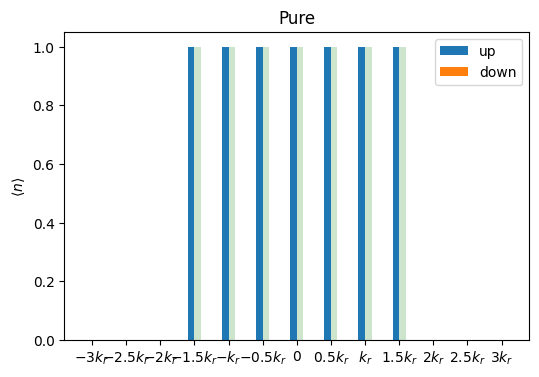

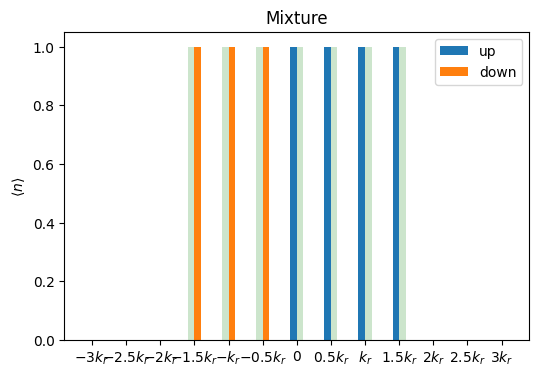

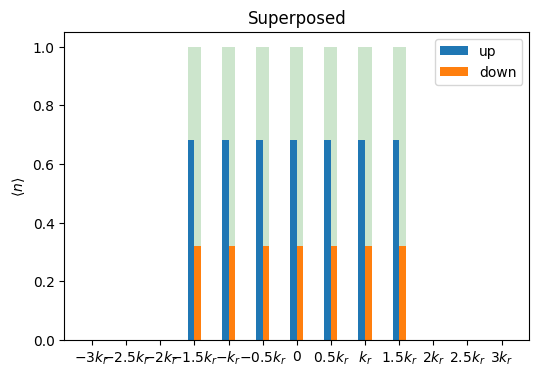

In [10]:
pure_nums, mixture_nums, superposed_nums = hilb.momentum_expected_numbers(np.stack([pure, mixture, superposed]))
plot_numbers(*pure_nums, tick_labels=k_tick_labels, title="Pure")
plot_numbers(*mixture_nums, tick_labels=k_tick_labels, title="Mixture")
plot_numbers(*superposed_nums, tick_labels=k_tick_labels, title="Superposed")

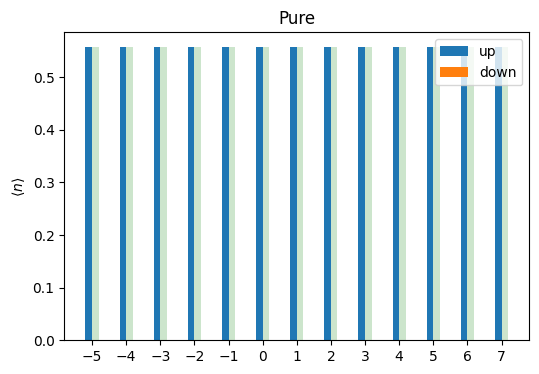

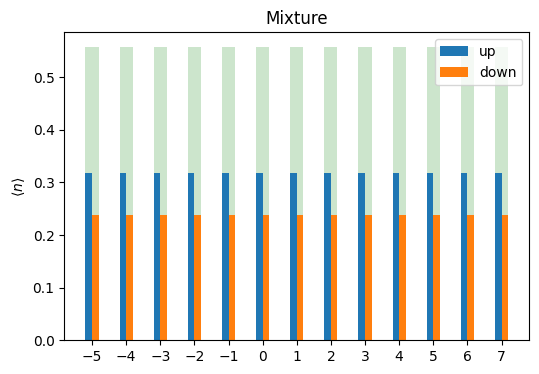

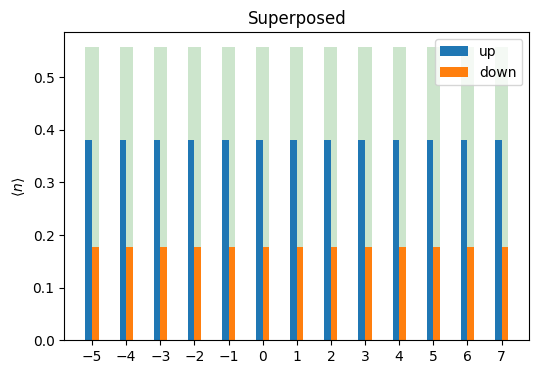

In [11]:
pure_nums, mixture_nums, superposed_nums = hilb.position_expected_numbers(np.stack([pure, mixture, superposed]))
plot_numbers(*pure_nums, title="Pure")
plot_numbers(*mixture_nums, title="Mixture")
plot_numbers(*superposed_nums, title="Superposed")

## Dynamics simulation

In [13]:
initial_state = pure
# initial_state = mixture
# initial_state = superposed

### SOC evolution

In [14]:
t0 = 0
t1 = 0.4 / 0.1129
n_timesteps = 101
save_at = np.linspace(t0, t1, n_timesteps)
step_size = save_at[1] - save_at[0]     

In [15]:
soc_hamiltonian = ybsoc.sparse_hamiltonian_scipy_csr(
    hilb,
    hbar=hbar,
    k_r=k_r,
    m_Yb=m_Yb,
    delta=delta,
    omega_R=omega_R,
    U=0.0
)

In [16]:
psis = scipy.sparse.linalg.expm_multiply(
    -1j * soc_hamiltonian / hbar,
    initial_state,
    start=t0,
    stop=t1,
    num=n_timesteps
)

nums = hilb.momentum_expected_numbers(psis)

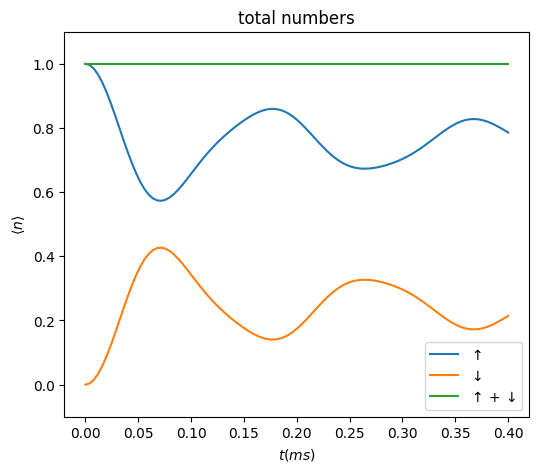

In [17]:
plt.figure(figsize=(6, 5))

total_up = np.sum(nums[:, 0, :], axis=1) / hilb.n_particles
total_down = np.sum(nums[:, 1, :], axis=1) / hilb.n_particles

plt.title("total numbers")

plt.plot(save_at * 0.1129, total_up, label="$\\uparrow$")
plt.plot(save_at * 0.1129, total_down, label="$\\downarrow$")
plt.plot(save_at * 0.1129, total_up + total_down, label="$\\uparrow + \\downarrow$")

plt.ylabel("$\\langle n \\rangle$")
plt.xlabel("$t (ms)$")
plt.ylim(-0.1, 1.1)

plt.legend()
plt.show()

C:\Users\pco0511\AppData\Local\Temp\ipykernel_33676\92489341.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


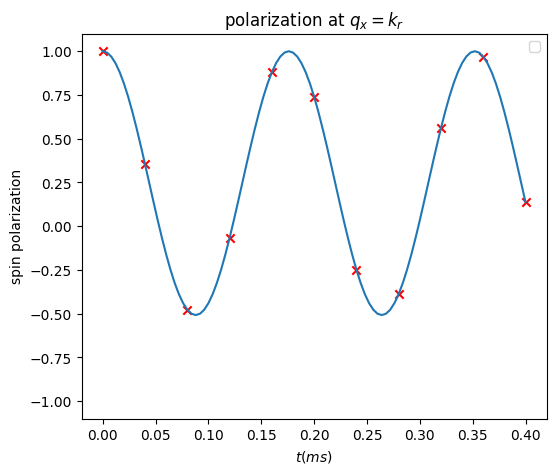

In [32]:
plt.figure(figsize=(6, 5))

plt.title("polarization at $q_x = k_r$")

n_up = nums[:, 0, 8]
n_down = nums[:, 1, 8]
num_polarization = (n_up - n_down) / (n_up + n_down)

plt.plot(save_at * 0.1129, num_polarization)
plt.scatter(save_at[0::10] * 0.1129, num_polarization[0::10], marker='x', color='red')

plt.ylabel("spin polarization")
plt.xlabel("$t (ms)$")
plt.ylim(-1.1, 1.1)

plt.legend()
plt.show()

### Loss Fraction Simulation:

In [ ]:
loss_time = 1.0 / 0.1129 # 1 ms
steps = 21

In [21]:
loss_hamiltonian = ybsoc.sparse_hamiltonian_scipy_csr(
    hilb,
    hbar=hbar,
    k_r=0.0,
    m_Yb=m_Yb,
    delta=0.0,
    omega_R=0.0,
    U=(-1j / 2) * gamma
)

In [24]:
initial_states = psis[0::5]
initial_nums = hilb.momentum_expected_numbers(initial_states)
initial_nums = np.sum(initial_nums[:, :, 8], axis=1)

In [30]:
psi_after_pa = scipy.sparse.linalg.expm_multiply(
    -1j * loss_hamiltonian * loss_time / hbar,
    rearrange(initial_states, "t i -> i t")
)
psi_after_pa = rearrange(psi_after_pa, "i t -> t i")
final_nums = hilb.momentum_expected_numbers(psi_after_pa)
final_nums = np.sum(final_nums[:, :, 8], axis=1)

In [31]:
loss_fractions = 1 - final_nums / initial_nums

C:\Users\pco0511\AppData\Local\Temp\ipykernel_33676\2816239453.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


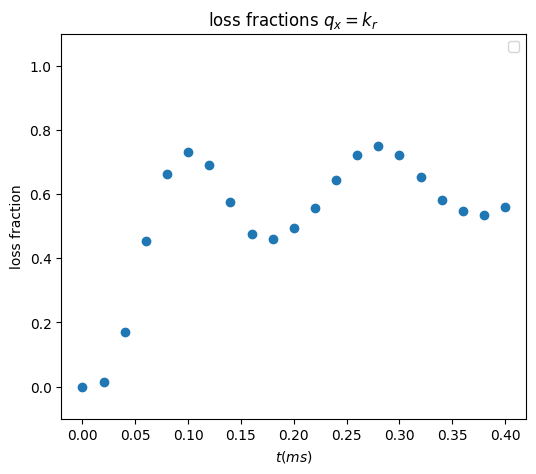

In [33]:
plt.figure(figsize=(6, 5))

plt.title("loss fractions $q_x = k_r$")

plt.scatter(save_at[0::5] * 0.1129, loss_fractions)

plt.ylabel("loss fraction")
plt.xlabel("$t (ms)$")
plt.ylim(-0.1, 1.1)

plt.legend()
plt.show()

## Plot & Save

In [34]:
exp_data_path1 = r"C:\workspace\yb-soc-two-body-loss\data\experiment\OneDrive_1_7-5-2025\unit_figure_4_b_upper.csv"
exp_data_path2 = r"C:\workspace\yb-soc-two-body-loss\data\experiment\OneDrive_1_7-5-2025\unit_figure_4_b_lower.csv"

In [35]:
df_upper = pd.read_csv(exp_data_path1)
exp_time = np.array(df_upper["time"]) * 1000 # s -> ms
exp_polarization = np.array(df_upper["mean"])


In [36]:
from scipy.optimize import curve_fit

def decaying_sine(t, a, b, c, d, e):
    return a + b * np.exp(c * t) * np.cos(d * t + e)

initial_guess = [0, 1, -0.1, 2, 0]
popt, pcov = curve_fit(decaying_sine, exp_time[:11], exp_polarization[:11], p0=initial_guess)

exp_pol_fit = decaying_sine(save_at * 0.1129, *popt)

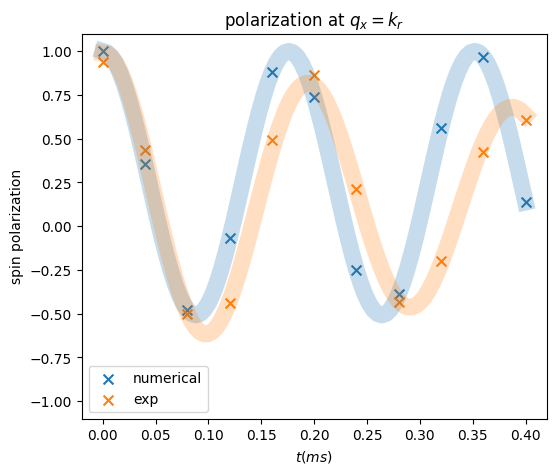

In [42]:
plt.figure(figsize=(6, 5))

plt.title("polarization at $q_x = k_r$")

plt.plot(save_at * 0.1129, num_polarization, linewidth=12, alpha=0.25, color='tab:blue')
plt.plot(save_at * 0.1129, exp_pol_fit, linewidth=12, alpha=0.25, color='tab:orange')

plt.scatter(save_at[0::10] * 0.1129, num_polarization[0::10], s=50, marker='x', color='tab:blue', label="numerical")
plt.scatter(exp_time[:11], exp_polarization[:11], s=50, marker='x', color='tab:orange', label="exp")

plt.ylabel("spin polarization")
plt.xlabel("$t (ms)$")
plt.ylim(-1.1, 1.1)

plt.legend()
plt.show()

In [51]:
df_lower = pd.read_csv(exp_data_path2)
exp_time = np.array(df_lower["time"]) * 1000 # s -> ms
exp_loss_fraction = np.array(df_lower["mean"])

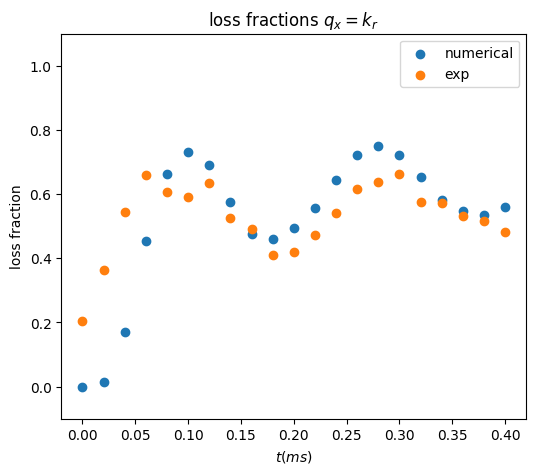

In [52]:
plt.figure(figsize=(6, 5))

plt.title("loss fractions $q_x = k_r$")

plt.scatter(save_at[0::5] * 0.1129, loss_fractions, label="numerical")
plt.scatter(exp_time, exp_loss_fraction, label="exp")

plt.ylabel("loss fraction")
plt.xlabel("$t (ms)$")
plt.ylim(-0.1, 1.1)

plt.legend()
plt.show()